In [1]:
import sys
sys.path.append('../')
from utils_models import *


(-1e-05, 0.001)

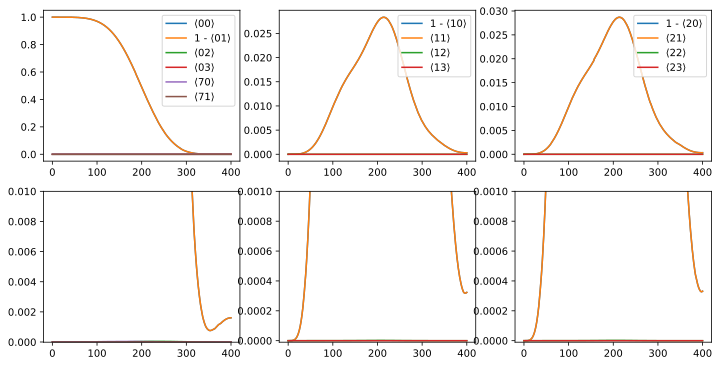

In [11]:
n_lvls_fluxonium = 20
n_lvls_transmon = 4


fluxonium = scqubits.Fluxonium(EJ=2.7,
                        EC=0.6,
                        EL=0.13,
                        flux=0,cutoff=110,
                        truncated_dim=n_lvls_fluxonium)
transmon = scqubits.Transmon(
    EJ=3.40890048e+01,
    EC=0.2,
    ng=0.0,
    ncut=10,
    truncated_dim = n_lvls_transmon
    )
system = FluxoniumTransmonSystem(
    fluxonium  = fluxonium,
    transmon = transmon,
    computaional_states = '1,2',
    g_strength = 0.2,
    # products_to_keep=[
    #     [ql,tl] for ql in [0,1,2] for tl in [0,1,2]
    # ]
    )
params =  [ 9.85457956e+01 , 1.06879003e-02 , 7.17592433e+00 ,-9.64997270e-04]

sigma = params[0]
amp_with_2pi = params[1]
w_d = params[2]
beta = params[3]

pulse_length = 400
tlist = np.linspace(0,pulse_length,int(pulse_length))

pulse_shape_args={
    'w_d': w_d,
    'amp': amp_with_2pi/(2*np.pi),
    'duration': pulse_length,
    'sigma': sigma,
    'beta':beta
}      

e_ops = []
for ql in range(8):
    for tl in range(4):
        e_ops.append(system.truncate_function(qutip.ket2dm(qutip.basis(system.hilbertspace.dimension, system.product_to_dressed[(ql,tl)]))))

results = system.run_qutip_mesolve_parrallel(
        initial_states = [system.truncate_function(qutip.basis(system.hilbertspace.dimension, system.product_to_dressed[(i,0)])) for i in range(3)],
        tlist = tlist,
        drive_terms = [DriveTerm( 
                driven_op=system.truncate_function(system.hilbertspace.op_in_dressed_eigenbasis(system.transmon.n_operator)),
                pulse_shape_func=modified_drag_pulse,
                pulse_shape_args=pulse_shape_args,
                )],
        c_ops = None,
        e_ops = e_ops
    )


colors = ['green','red','darkorange']
fig,axes = plt.subplots(2,3,figsize = (12,6))
for col, levels_list in zip([0,1,2],
                    [[(ql,tl)  for ql in [0] for tl in range(4)]+[(7,0),(7,1)],
                     [(ql,tl)  for ql in [1] for tl in range(4)],
                     [(ql,tl)  for ql in [2] for tl in range(4)]
                        # [(0,0),(0,1),(7,0),(7,1)],
                        # [(1,0),(1,1),(0,0)],
                        # [(2,0),(2,1),(0,0)]
                    ]):
    for row in [0,1]:
        for (ql,tl) in levels_list:
            i = ql*4+tl
            if (ql,tl) not in [(0,1), (1,0),(2,0)]:
                axes[row, col].plot(tlist,results[col].expect[i],label = rf"$\langle{ql}{tl}\rangle$")
            else:
                axes[row, col].plot(tlist,1 - results[col].expect[i],label = rf"1 - $\langle{ql}{tl}\rangle$")
    axes[0,col].legend()
    # axes[1,col].axvline(x=270, color='b', linestyle='--')
    # axes[1,col].set_xlim(260,280)

axes[1,0].set_ylim(-1e-5,1e-2)
axes[1,1].set_ylim(-1e-5,1e-3)
axes[1,2].set_ylim(-1e-5,1e-3)


 /Users/jiakaiwang/opt/miniconda3/envs/tensorflow/lib/python3.10/site-packages/loky/backend/fork_exec.py: 38

 Total run time:  40.46s*] Elapsed 40.46s / Remaining 00:00:00:00
 [*********98%***********] Elapsed 40.56s / Remaining 00:00:00:00

Processing states with pad_back_custom: 100%|██████████| 400/400 [00:00<00:00, 6171.04it/s]


 Total run time:  41.36s*] Elapsed 41.36s / Remaining 00:00:00:00


Processing states with pad_back_custom: 100%|██████████| 400/400 [00:00<00:00, 6486.66it/s]


 Total run time:  42.57s*] Elapsed 42.57s / Remaining 00:00:00:00


Processing states with pad_back_custom: 100%|██████████| 400/400 [00:00<00:00, 5309.53it/s]


(-1e-05, 0.001)

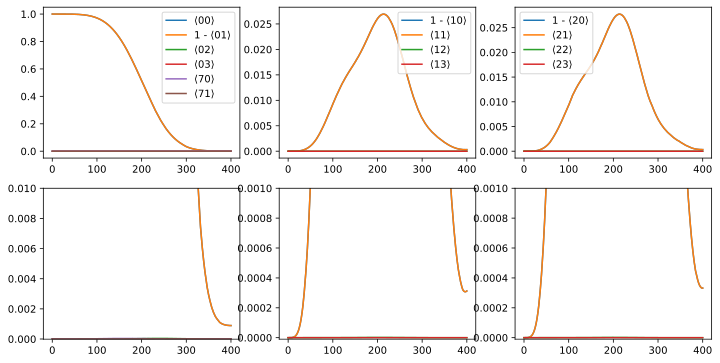

In [14]:
n_lvls_fluxonium = 20
n_lvls_transmon = 4


fluxonium = scqubits.Fluxonium(EJ=2.7,
                        EC=0.6,
                        EL=0.13,
                        flux=0,cutoff=110,
                        truncated_dim=n_lvls_fluxonium)
transmon = scqubits.Transmon(
    EJ=3.40890048e+01,
    EC=0.2,
    ng=0.0,
    ncut=10,
    truncated_dim = n_lvls_transmon
    )
system = FluxoniumTransmonSystem(
    fluxonium  = fluxonium,
    transmon = transmon,
    computaional_states = '1,2',
    g_strength = 0.2,
    # products_to_keep=[
    #     [ql,tl] for ql in [0,1,2] for tl in [0,1,2]
    # ]
    )
params =  [ 9.85457956e+01 , 0.0103879003 , 7.17592433e+00 ,-9.64997270e-04]

sigma = params[0]
amp_with_2pi = params[1]
w_d = params[2]
beta = params[3]

pulse_length = 400
tlist = np.linspace(0,pulse_length,int(pulse_length))

pulse_shape_args={
    'w_d': w_d,
    'amp': amp_with_2pi/(2*np.pi),
    'duration': pulse_length,
    'sigma': sigma,
    'beta':beta
}      

e_ops = []
for ql in range(8):
    for tl in range(4):
        e_ops.append(system.truncate_function(qutip.ket2dm(qutip.basis(system.hilbertspace.dimension, system.product_to_dressed[(ql,tl)]))))

results = system.run_qutip_mesolve_parrallel(
        initial_states = [system.truncate_function(qutip.basis(system.hilbertspace.dimension, system.product_to_dressed[(i,0)])) for i in range(3)],
        tlist = tlist,
        drive_terms = [DriveTerm( 
                driven_op=system.truncate_function(system.hilbertspace.op_in_dressed_eigenbasis(system.transmon.n_operator)),
                pulse_shape_func=modified_drag_pulse,
                pulse_shape_args=pulse_shape_args,
                )],
        c_ops = None,
        e_ops = e_ops
    )


colors = ['green','red','darkorange']
fig,axes = plt.subplots(2,3,figsize = (12,6))
for col, levels_list in zip([0,1,2],
                    [[(ql,tl)  for ql in [0] for tl in range(4)]+[(7,0),(7,1)],
                     [(ql,tl)  for ql in [1] for tl in range(4)],
                     [(ql,tl)  for ql in [2] for tl in range(4)]
                        # [(0,0),(0,1),(7,0),(7,1)],
                        # [(1,0),(1,1),(0,0)],
                        # [(2,0),(2,1),(0,0)]
                    ]):
    for row in [0,1]:
        for (ql,tl) in levels_list:
            i = ql*4+tl
            if (ql,tl) not in [(0,1), (1,0),(2,0)]:
                axes[row, col].plot(tlist,results[col].expect[i],label = rf"$\langle{ql}{tl}\rangle$")
            else:
                axes[row, col].plot(tlist,1 - results[col].expect[i],label = rf"1 - $\langle{ql}{tl}\rangle$")
    axes[0,col].legend()
    # axes[1,col].axvline(x=270, color='b', linestyle='--')
    # axes[1,col].set_xlim(260,280)

axes[1,0].set_ylim(-1e-5,1e-2)
axes[1,1].set_ylim(-1e-5,1e-3)
axes[1,2].set_ylim(-1e-5,1e-3)
